In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [18]:
load_dotenv()
model = ChatOpenAI(model='gpt-4o-mini')

In [19]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description = 'Sentiment of Schema')

In [20]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [21]:
structured_model = model.with_structured_output(SentimentSchema)
prompt = 'What is the sentiment of the follwoing review - The software is bloaty'
structured_model.invoke(prompt).sentiment

'negative'

In [22]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive","negative"]
    diagnosis: dict
    response: str

In [23]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [26]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following reveiw find out the sentiment \n {state['review']}'
    sentiment = structured_model.invoke(prompt).sentiment
    
    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response","run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
    
    

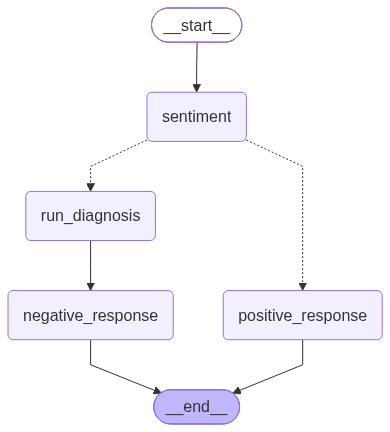

In [31]:
graph = StateGraph(ReviewState)

graph.add_node('sentiment',find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)

graph.add_edge(START,'sentiment')
graph.add_conditional_edges('sentiment',check_sentiment)
graph.add_edge('positive_response',END)

graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow=  graph.compile()
workflow

In [32]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Bug Issue\n\nHi [User's Name],\n\nI hope this message finds you well. I understand how frustrating it can be when things aren't working as they should, especially when you're counting on them. Your concerns are very important to us, and I appreciate you bringing this issue to our attention.\n\nTo better assist you, could you please provide a few more details about the bug you’re experiencing? Specifically, any error messages you’ve received, what actions you were taking when the issue arose, and the device or platform you are using would be incredibly helpful.\n\nRest assured, we’re committed